In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pydub import AudioSegment
import os

# Load the audio file
audio = AudioSegment.from_file("./out_ws/1763698634943.wav")

# Get file info
print(f"Duration: {len(audio)} ms ({len(audio)/1000:.2f} seconds)")
print(f"Sample rate: {audio.frame_rate} Hz")
print(f"Channels: {audio.channels}")
print(f"Sample width: {audio.sample_width} bytes")
print(f"Frame count: {audio.frame_count()}")
print(f"File size: {os.path.getsize('./out_ws/1763698634943.wav')} bytes")


Duration: 1860 ms (1.86 seconds)
Sample rate: 48000 Hz
Channels: 1
Sample width: 4 bytes
Frame count: 89280.0
File size: 357164 bytes


In [3]:
import numpy as np

# Convert AudioSegment to numpy array
audio_array = np.array(audio.get_array_of_samples())

# For stereo files, reshape to 2D array
if audio.channels == 2:
    audio_array = audio_array.reshape((-1, 2))

print(f"Array shape: {audio_array.shape}")
print(f"Data type: {audio_array.dtype}")

Array shape: (89280,)
Data type: int32


In [4]:
# Convert numpy array back to AudioSegment
audio_back = AudioSegment(
    audio_array.tobytes(),
    frame_rate=audio.frame_rate,
    sample_width=audio.sample_width,
    channels=audio.channels
)


In [5]:
audio

In [6]:
audio_back

In [7]:
import numpy as np
from scipy import signal
import librosa

# Normalize audio to [-1, 1] range
audio_normalized = audio_array.astype(np.float32) / np.max(np.abs(audio_array))

# 1. Spectrogram (STFT)
f, t, Sxx = signal.spectrogram(audio_normalized, fs=audio.frame_rate)

# 2. Mel-spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio_normalized, sr=audio.frame_rate)

# 3. MFCC (Mel-frequency cepstral coefficients)
mfccs = librosa.feature.mfcc(y=audio_normalized, sr=audio.frame_rate, n_mfcc=13)

# 4. Chroma features
chroma = librosa.feature.chroma_stft(y=audio_normalized, sr=audio.frame_rate)

# 5. Spectral centroid
spectral_centroids = librosa.feature.spectral_centroid(y=audio_normalized, sr=audio.frame_rate)

# 6. Zero crossing rate
zcr = librosa.feature.zero_crossing_rate(audio_normalized)


In [9]:
import numpy as np
from scipy import signal
import librosa

# Normalize audio
audio_normalized = audio_array.astype(np.float32) / np.max(np.abs(audio_array))

# 1. Spectrogram Analysis
f, t, Sxx = signal.spectrogram(audio_normalized, fs=audio.frame_rate)
dominant_freq = f[np.argmax(np.mean(Sxx, axis=1))]
print(f"Dominant frequency: {dominant_freq:.1f} Hz")

# 2. Mel-spectrogram Analysis
mel_spec = librosa.feature.melspectrogram(y=audio_normalized, sr=audio.frame_rate)
mel_energy = np.mean(mel_spec)
print(f"Average mel energy: {mel_energy:.3f}")

# 3. MFCC Analysis (speech characteristics)
mfccs = librosa.feature.mfcc(y=audio_normalized, sr=audio.frame_rate, n_mfcc=13)
mfcc_mean = np.mean(mfccs, axis=1)
print(f"MFCC coefficients mean: {mfcc_mean[:3]}")

# 4. Chroma Analysis (pitch content)
chroma = librosa.feature.chroma_stft(y=audio_normalized, sr=audio.frame_rate)
dominant_pitch = np.argmax(np.mean(chroma, axis=1))
pitch_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
print(f"Dominant pitch class: {pitch_names[dominant_pitch]}")

# 5. Spectral Centroid (brightness)
spectral_centroids = librosa.feature.spectral_centroid(y=audio_normalized, sr=audio.frame_rate)
brightness = np.mean(spectral_centroids)
print(f"Audio brightness: {brightness:.1f} Hz")

# 6. Zero Crossing Rate (noisiness/voicing)
zcr = librosa.feature.zero_crossing_rate(audio_normalized)
zcr_mean = np.mean(zcr)
print(f"Zero crossing rate: {zcr_mean:.3f}")


Dominant frequency: 187.5 Hz
Average mel energy: 1.744
MFCC coefficients mean: [-337.9377051   167.2686062   -12.59199442]
Dominant pitch class: B
Audio brightness: 2292.5 Hz
Zero crossing rate: 0.059


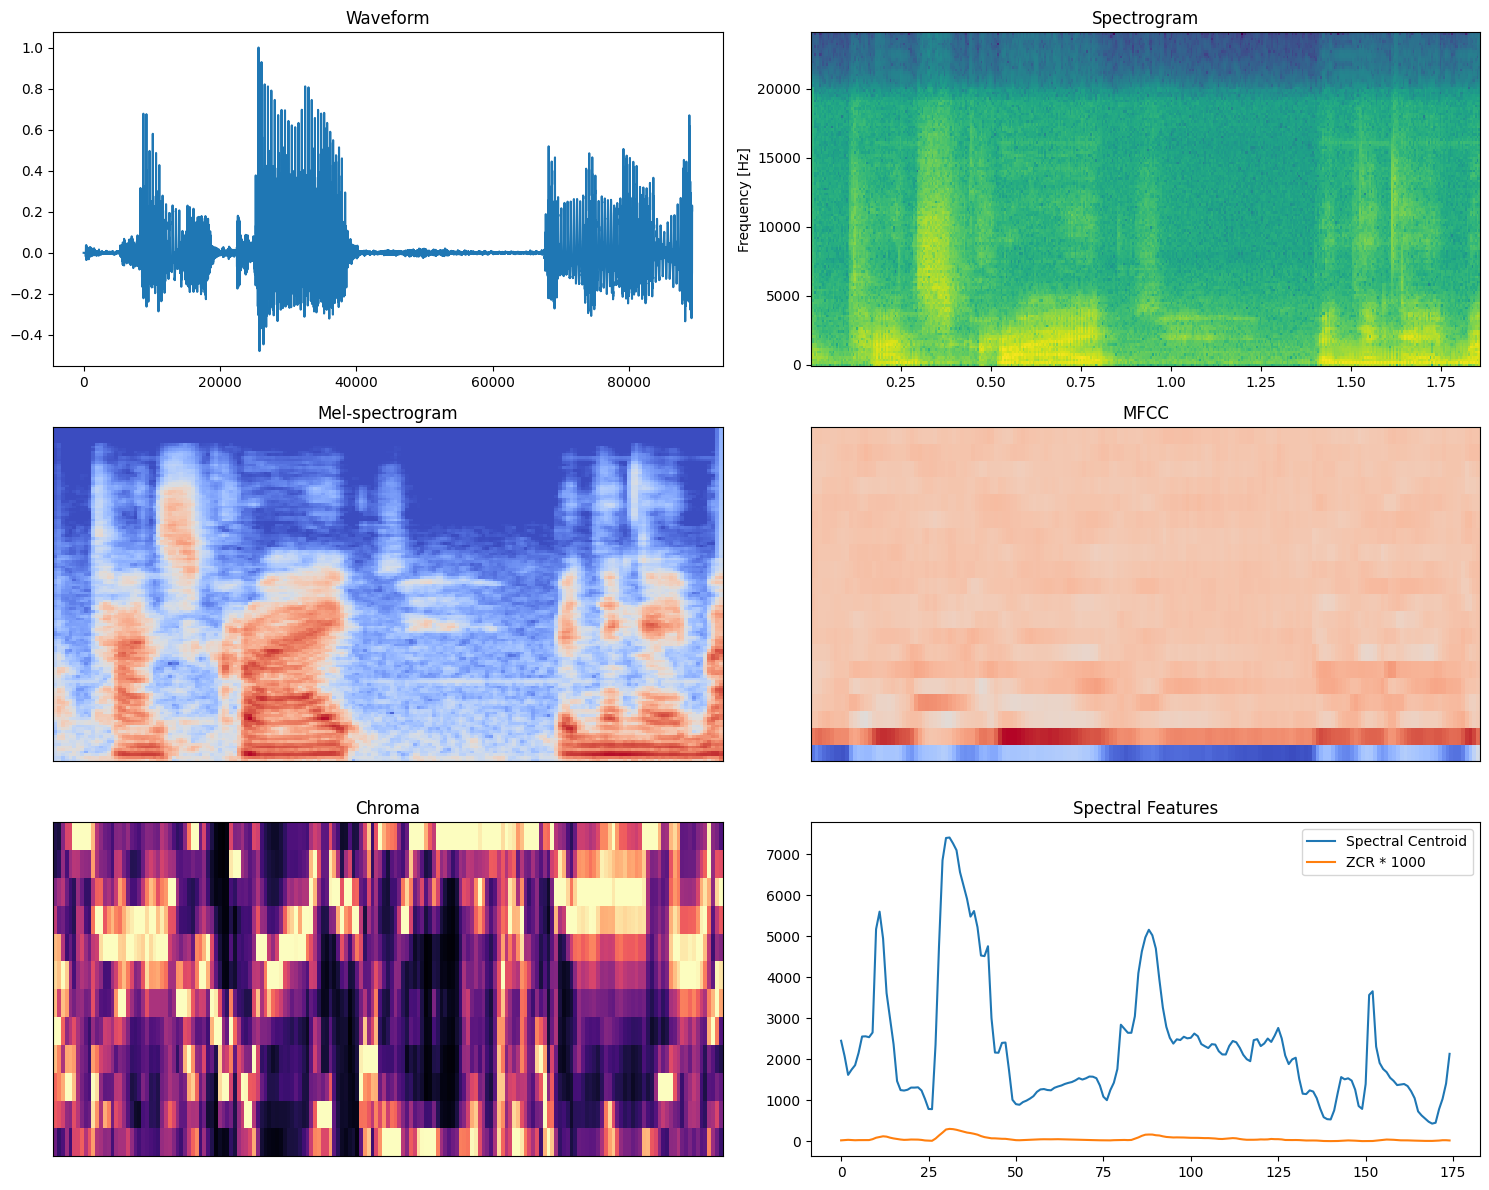

In [11]:
import matplotlib.pyplot as plt
import librosa.display

# Normalize audio
audio_normalized = audio_array.astype(np.float32) / np.max(np.abs(audio_array))

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# 1. Waveform
axes[0,0].plot(audio_normalized)
axes[0,0].set_title('Waveform')

# 2. Spectrogram
f, t, Sxx = signal.spectrogram(audio_normalized, fs=audio.frame_rate)
axes[0,1].pcolormesh(t, f, 10 * np.log10(Sxx))
axes[0,1].set_title('Spectrogram')
axes[0,1].set_ylabel('Frequency [Hz]')

# 3. Mel-spectrogram
mel_spec = librosa.feature.melspectrogram(y=audio_normalized, sr=audio.frame_rate)
librosa.display.specshow(librosa.power_to_db(mel_spec), ax=axes[1,0])
axes[1,0].set_title('Mel-spectrogram')

# 4. MFCC
mfccs = librosa.feature.mfcc(y=audio_normalized, sr=audio.frame_rate)
librosa.display.specshow(mfccs, ax=axes[1,1])
axes[1,1].set_title('MFCC')

# 5. Chroma
chroma = librosa.feature.chroma_stft(y=audio_normalized, sr=audio.frame_rate)
librosa.display.specshow(chroma, ax=axes[2,0])
axes[2,0].set_title('Chroma')

# 6. Spectral features
spectral_centroids = librosa.feature.spectral_centroid(y=audio_normalized, sr=audio.frame_rate)
zcr = librosa.feature.zero_crossing_rate(audio_normalized)
axes[2,1].plot(spectral_centroids[0], label='Spectral Centroid')
axes[2,1].plot(zcr[0] * 1000, label='ZCR * 1000')
axes[2,1].set_title('Spectral Features')
axes[2,1].legend()

plt.tight_layout()
plt.show()
